<a href="https://colab.research.google.com/github/NobodydeBunny/Cat_Dog_breed_classifire_AI_model/blob/main/Dogs_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from collections import defaultdict, Counter
import random

In [2]:
(dataset, info) = tfds.load("oxford_iiit_pet",
                            with_info=True,
                            as_supervised=True)

train_ds = dataset['train']
test_ds = dataset['test']
class_names = info.features['label'].names

In [3]:
cat_labels = tf.constant(
    [i for i, name in enumerate(class_names) if name[0].isupper()],
    dtype=tf.int64
)

def is_cat(image, label):
    return tf.reduce_any(tf.equal(cat_labels, label))

train_ds = train_ds.filter(is_cat)
test_ds = test_ds.filter(is_cat)

cat_class_names = [class_names[i] for i in cat_labels.numpy()]
NUM_CLASSES = len(cat_class_names)

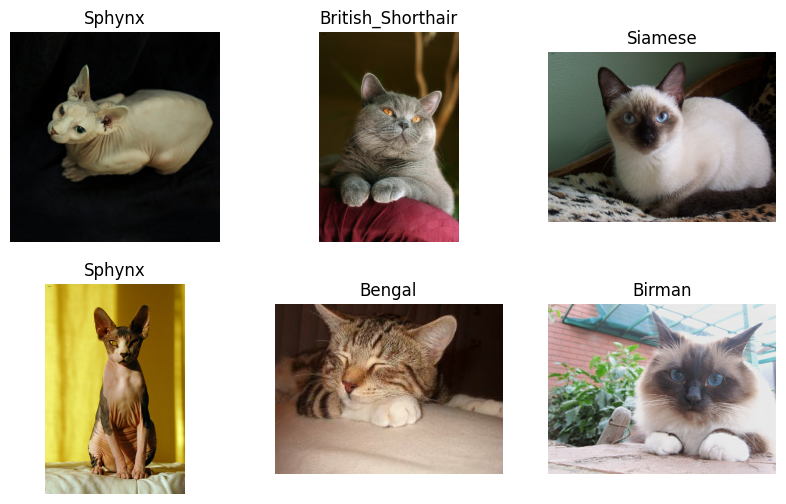

In [4]:
plt.figure(figsize=(10,6))

label_map = {int(original_idx): new_idx for new_idx, original_idx in enumerate(cat_labels.numpy())}

for i, (image, label) in enumerate(train_ds.take(6)):
    plt.subplot(2, 3, i+1)
    plt.imshow(image)
    plt.title(cat_class_names[label_map[int(label.numpy())]])
    plt.axis('off')

plt.show()

In [5]:
IMG_SIZE = 225

all_cats_ds = train_ds.concatenate(test_ds)

class_images = defaultdict(list)

for image, label in all_cats_ds:
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.cast(image, tf.float32) / 255.0
    class_images[int(label.numpy())].append((image, int(label.numpy())))

train_list, val_list, test_list = [], [], []

train_ratio = 0.8
val_ratio = 0.1

for class_idx, images in class_images.items():
    random.shuffle(images)

    total = len(images)
    n_train = int(total * train_ratio)
    n_val = int(n_train * val_ratio)
    n_train -= n_val

    train_list.extend(images[:n_train])
    val_list.extend(images[n_train:n_train+n_val])
    test_list.extend(images[n_train+n_val:])

def make_dataset(data_list):
    images = tf.stack([img for img, _ in data_list])
    labels = tf.constant([lbl for _, lbl in data_list], dtype=tf.int64)
    return tf.data.Dataset.from_tensor_slices((images, labels))

train_ds = make_dataset(train_list)
val_ds   = make_dataset(val_list)
test_ds  = make_dataset(test_list)

print("Train:", len(train_list))
print("Validation:", len(val_list))
print("Test:", len(test_list))

Train: 1709
Validation: 187
Test: 475


In [6]:
BATCH_SIZE = 32

label_table = tf.lookup.StaticHashTable(
    tf.lookup.KeyValueTensorInitializer(
        keys=tf.constant(list(label_map.keys()), dtype=tf.int64),
        values=tf.constant(list(label_map.values()), dtype=tf.int64),
    ),
    default_value=-1
)

def preprocess(image, label):
    label = label_table.lookup(label)
    return image, label

train_ds = train_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
val_ds   = val_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
test_ds  = test_ds.map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)

train_ds = train_ds.shuffle(len(train_list)).batch(BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.shuffle(len(val_list)).batch(BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE, drop_remainder=True).prefetch(tf.data.AUTOTUNE)

print("Datasets ready.")

Datasets ready.


Image shape: (32, 225, 225, 3)
Label values: [ 6  4  0  7  4  8  0 11  1  5  6  4  8  3  3  5 10 10  3  6  3  7  8  7
 11  2  1  9 11 11  1  5]


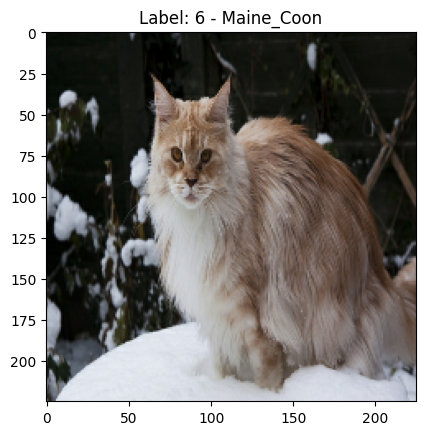

In [7]:
# Check a few samples from the dataset
for images, labels in train_ds.take(1):
    print("Image shape:", images.shape)      # Should be (32,225,225,3)
    print("Label values:", labels.numpy())   # Should be integers 0–11
    # Display one image
    import matplotlib.pyplot as plt
    plt.imshow(images[0])
    plt.title(f"Label: {labels[0].numpy()} - {cat_class_names[labels[0].numpy()]}")
    plt.show()

In [8]:
def show_class_distribution(dataset, name):
    counter = Counter()

    for _, labels in dataset.unbatch():
        counter[int(labels.numpy())] += 1

    print(f"\n{name} Distribution")
    total = sum(counter.values())
    for cls, count in sorted(counter.items()):
        print(f"{cat_class_names[cls]:<25} : {count}")
    print("Total:", total)

show_class_distribution(train_ds, "Train")
show_class_distribution(val_ds, "Validation")
show_class_distribution(test_ds, "Test")


Train Distribution
Abyssinian                : 143
Bengal                    : 143
Birman                    : 143
Bombay                    : 133
British_Shorthair         : 143
Egyptian_Mau              : 134
Maine_Coon                : 144
Persian                   : 143
Ragdoll                   : 142
Russian_Blue              : 143
Siamese                   : 142
Sphynx                    : 143
Total: 1696

Validation Distribution
Abyssinian                : 12
Bengal                    : 10
Birman                    : 15
Bombay                    : 14
British_Shorthair         : 16
Egyptian_Mau              : 14
Maine_Coon                : 14
Persian                   : 14
Ragdoll                   : 12
Russian_Blue              : 14
Siamese                   : 11
Sphynx                    : 14
Total: 160

Test Distribution
Abyssinian                : 40
Bengal                    : 40
Birman                    : 40
Bombay                    : 37
British_Shorthair         : 40
Eg

In [9]:
for x, y in train_ds.take(1):
    print(x.shape, y.shape)
    print(tf.reduce_min(x), tf.reduce_max(x))

(32, 225, 225, 3) (32,)
tf.Tensor(0.0, shape=(), dtype=float32) tf.Tensor(1.0, shape=(), dtype=float32)


In [10]:
for x, y in val_ds.take(1):
    print(tf.reduce_min(x), tf.reduce_max(x))

tf.Tensor(0.0, shape=(), dtype=float32) tf.Tensor(1.0, shape=(), dtype=float32)


In [11]:
for img, label in val_ds.take(5):
    print(label.numpy())

[ 3  4  8  9  7  7  5  3  2  1  4  6  6  9  3  5  5  8  5 11  8  0  7  2
  5 11  0  3  6 11  2  0]
[ 9  1  9  2  1  3 10  9 11  1 11  8  8  8  8 10  6 11  0  1  5  3 11 10
  7  1 10  7  7  4 11  7]
[ 4 11 11  9  8  3  4  4  3  6  1  9 10  2  2  1  2 10 11 11  6  2  5  4
  3  9  1  5  5  0  3  6]
[ 8  1  7  2  1  8  2  8  0  0  7  0 10  0  0  7  2  3  2  6  8  0  2 10
  6  1  3 10  9  7  9 11]
[ 6 10  6  5  4 10  9  9  1  0  7 10  5 10  4  1  4  7  4  8  9  9  0  6
  2  5  1  9  8 11  7  1]


In [31]:
INIT_LR = 1e-2                # higher initial LR
MIN_LR = 1e-4
TOTAL_EPOCHS = 100
BATCH_SIZE = 32
WEIGHT_DECAY = 1e-5           # reduced weight decay
PATIENCE = 10
WARMUP_EPOCHS = 5

# Cosine decay after warmup
total_train_steps = (len(train_list) // BATCH_SIZE) * TOTAL_EPOCHS
warmup_steps = (len(train_list) // BATCH_SIZE) * WARMUP_EPOCHS

def lr_scheduler(epoch):
    if epoch < WARMUP_EPOCHS:
        # linear warmup
        return INIT_LR * (epoch + 1) / WARMUP_EPOCHS
    else:
        # cosine decay after warmup
        progress = (epoch - WARMUP_EPOCHS) / (TOTAL_EPOCHS - WARMUP_EPOCHS)
        return MIN_LR + 0.5 * (INIT_LR - MIN_LR) * (1 + tf.math.cos(tf.constant(3.14159) * progress))

In [32]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [33]:
model = tf.keras.Sequential([

    data_augmentation,

    # First Convolutional Block
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),

    # Second Convolutional Block
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),

    # Third Convolutional Block
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),

    # Fourth Convolutional Block
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),

    # Fifth Convolutional Block
    tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [35]:
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=INIT_LR,           # we'll override with callback
    weight_decay=WEIGHT_DECAY,
    clipnorm=1.0                     # gradient clipping
)
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [36]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=PATIENCE,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_model.keras',
        monitor='val_accuracy',
        save_best_only=True
    )
]

In [37]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=TOTAL_EPOCHS,
    callbacks=callbacks
)

Epoch 1/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 414ms/step - accuracy: 0.1086 - loss: 3.7027 - val_accuracy: 0.0875 - val_loss: 3400.4617
Epoch 2/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 21s 375ms/step - accuracy: 0.0990 - loss: 2.9982 - val_accuracy: 0.0938 - val_loss: 69.0675
Epoch 3/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 366ms/step - accuracy: 0.1308 - loss: 2.8005 - val_accuracy: 0.0875 - val_loss: 11.8590
Epoch 4/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 21s 375ms/step - accuracy: 0.1449 - loss: 2.6953 - val_accuracy: 0.0938 - val_loss: 5.0031
Epoch 5/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 21s 381ms/step - accuracy: 0.1502 - loss: 2.5664 - val_accuracy: 0.1187 - val_loss: 2.6270
Epoch 6/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 21s 376ms/step - accuracy: 0.1487 - loss: 2.5514 - val_accuracy: 0.1875 - val_loss: 3.0237
Epoch 7/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 368ms/step - accuracy: 0.1563 - loss: 2.4427 - val_accuracy: 0.1312 - val_loss: 2.5106
Epoch 8/100
53/53 ━━━━━━━━━━━━━━━━━━━━ 20s 368ms/step - accuracy: 0.1612 - loss: 2.43

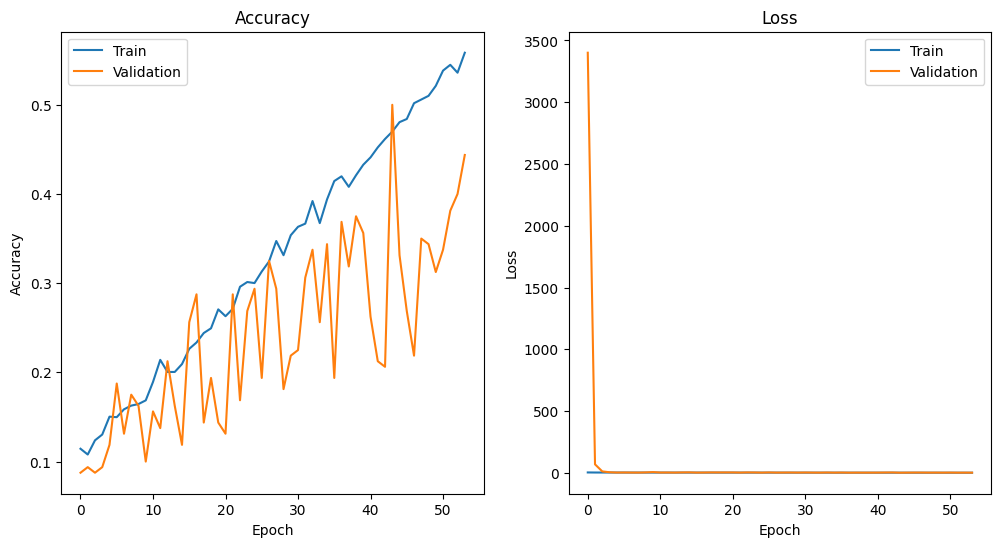

In [38]:
plt.figure(figsize=(12,6))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [39]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.3834 - loss: 1.7872
Test Loss: 1.6341
Test Accuracy: 0.4196


In [40]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=cat_class_names))

                   precision    recall  f1-score   support

       Abyssinian       0.38      0.20      0.26        40
           Bengal       0.39      0.78      0.52        40
           Birman       0.40      0.53      0.45        40
           Bombay       0.80      0.86      0.83        37
British_Shorthair       0.50      0.15      0.23        40
     Egyptian_Mau       0.66      0.55      0.60        38
       Maine_Coon       0.27      0.33      0.30        40
          Persian       0.24      0.54      0.33        13
          Ragdoll       0.50      0.12      0.20        40
     Russian_Blue       0.48      0.38      0.42        40
          Siamese       0.45      0.38      0.41        40
           Sphynx       0.24      0.35      0.28        40

         accuracy                           0.42       448
        macro avg       0.44      0.43      0.40       448
     weighted avg       0.45      0.42      0.40       448



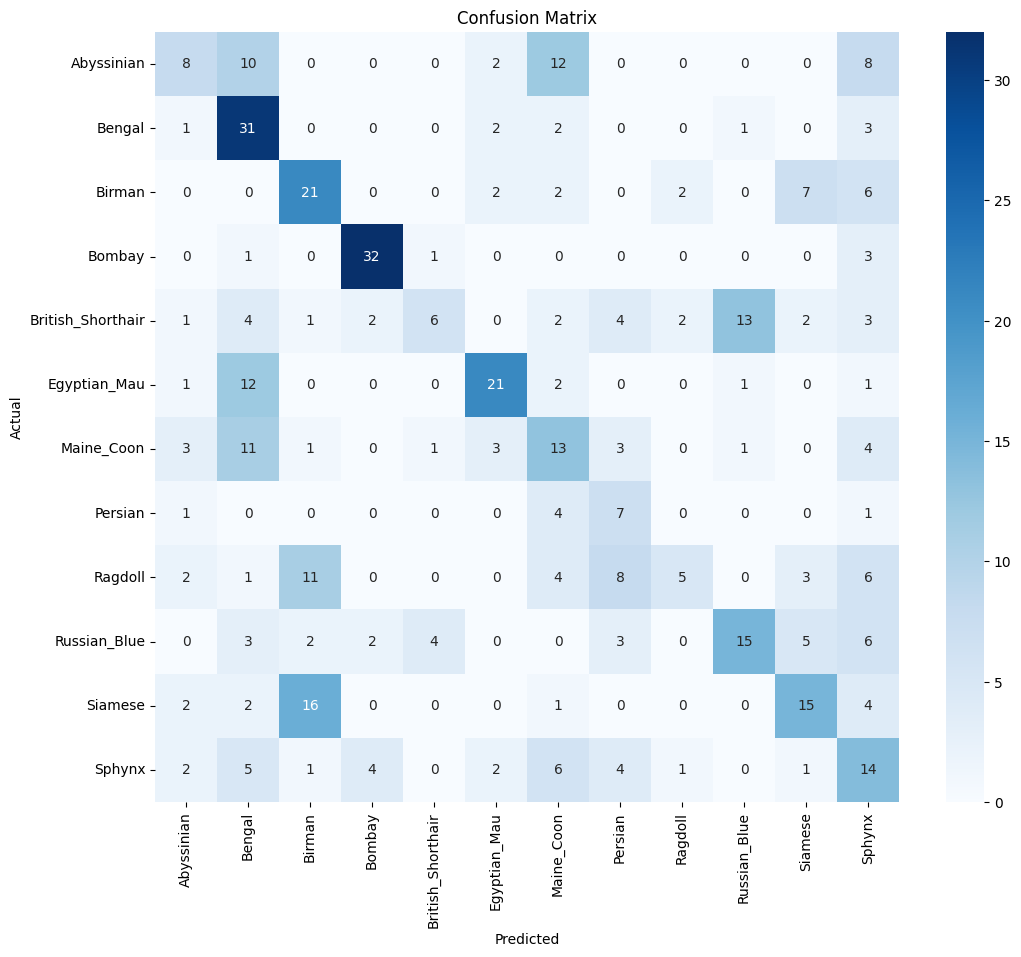

In [41]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=cat_class_names,
            yticklabels=cat_class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [42]:
def predict_and_display_random():
    test_list = list(test_ds.unbatch())

    index = random.randint(0, len(test_list) - 1)

    image, label = test_list[index]
    input_img = tf.expand_dims(image, axis=0)

    probs = model.predict(input_img, verbose=0)[0]
    pred_class = np.argmax(probs)

    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.imshow(image)
    plt.title(f"True: {cat_class_names[label.numpy()]}")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.barh(cat_class_names, probs*100)
    plt.xlim(0, 100)
    plt.title(f"Predicted: {cat_class_names[pred_class]}")
    plt.show()

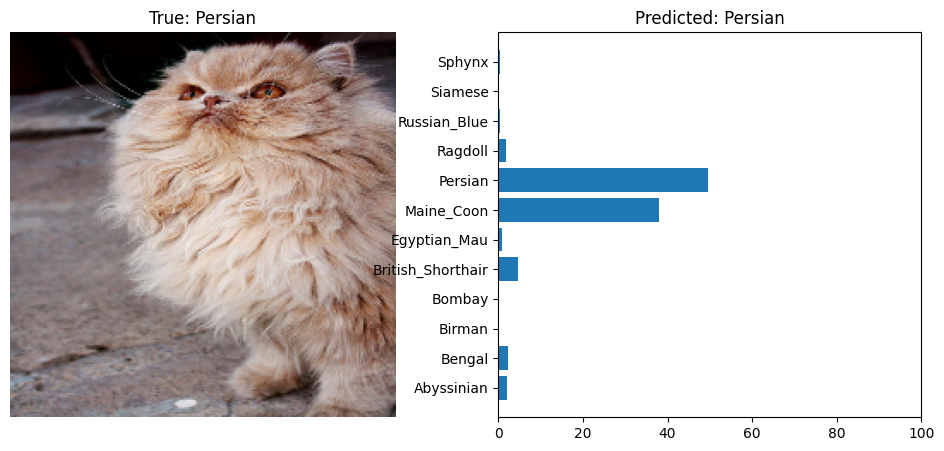

In [50]:
predict_and_display_random()

In [51]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
model.save("/content/drive/MyDrive/Colab Notebooks/cat_breed_model_v8.keras")
print("Model saved successfully.")

Model saved successfully.
